# Attempt-level table + EDA — value axis in the ICRL corpus

## The data structure (read this first)

```
conversation = one hidden criterion,  3-8 paragraphs   (mean 5.45, median 5, n=380)
paragraph    = one Wikipedia source text, 1-5 attempts, ends when the model earns +1
attempt      = one hypothesis + one rewrite + (usually) one +1/-1 feedback turn
```

A paragraph is **not** one hypothesis. Every retry carries a *new* hypothesis: 100% of
multi-attempt paragraphs have distinct reasoning, and 81% change judge label within the
paragraph. **The attempt is the unit of analysis.**

## The 2x2

Whether the ATTEMPT succeeded (the `+1`/`-1` the game returned) crossed with whether the
REASONING named the true criterion (a codex-CLI judge over all 4,516 `<think>` blocks,
which never saw the reward).

| code | reward | reasoning | meaning | n |
|---|---|---|---|---|
| `RC` | +1 | correct | succeeded, and knew why | 1834 |
| `RW` | +1 | wrong | succeeded on a wrong hypothesis — **"lucky"** | **34** |
| `FC` | -1 | correct | named the rule but botched execution | 62 |
| `FW` | -1 | wrong | ordinary failing guess | 2383 |
| `NF` | none | — | last failing attempt of a round; game moved on, no feedback turn | 202 |

`[RC]` in a sequence marks the **scripted discovery** — the successful attempt inside the
corpus's `discovery_paragraph`.

## Judge validation

97.8% agreement between "named the rule" and "got +1", from text that never contained the
reward. A 20-item stratified sample is printed by `validate_labels.py`.

## What the corpus does NOT support

The lucky-vs-earned test (`RW` vs `RC`) needs unpredicted rewards. **There are 34.** The
generator wrote a hypothesis and then a paragraph implementing it, so a wrong hypothesis
almost never satisfies the criterion by accident. Separately, `discovery_paragraph` is
systematically late — 63.7% of conversations name the rule earlier, mean 1.4 paragraphs —
so any split defined by that field is contaminated. Both facts are visible directly in the
sequences below, as `RC` tokens appearing well before `[RC]`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
for p in (ROOT, ROOT / "value-axis", ROOT / "value-axis" / "construction"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "figure.facecolor": "white"})
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

CSV = ROOT / "results" / "attempt_table.csv"
if CSV.exists():
    df = pd.read_csv(CSV)
    seq = pd.read_csv(ROOT / "results" / "attempt_sequences.csv")
else:                       # ~1 min: re-tokenises every conversation
    from attempt_table import build, sequences
    df = build(); seq = sequences(df)
    df.to_csv(CSV, index=False)
    seq.to_csv(ROOT / "results" / "attempt_sequences.csv", index=False)

FIGS = ROOT / "figures"; FIGS.mkdir(exist_ok=True)
CODES = ["RC", "RW", "FC", "FW", "NF"]
COL = {"RC": "#2f855a", "RW": "#2b6cb0", "FC": "#b7791f", "FW": "#c05621", "NF": "#a0aec0"}

print(f"{len(df):,} attempts | {df.conv_id.nunique()} conversations | "
      f"{df.reward_fn.nunique()} reward functions")
display(df.code.value_counts().rename("n").to_frame().T)
print("\ncolumns:", list(df.columns))

4,516 attempts | 380 conversations | 48 reward functions


code,FW,RC,NF,FC,RW,FU
n,2383,1834,202,62,34,1



columns: ['conv_id', 'reward_fn', 'criterion', 'attempt_idx', 'paragraph', 'attempt_in_paragraph', 'discovery_paragraph', 'reward', 'reason', 'code', 'is_synth_discovery', 'leak', 'think', 'proj', 'proj_heldout', 'n_heldout_splits', 'proj_asst', 'n_asst_tokens', 'n_attempts_so_far', 'n_plus1_so_far']


## The table

One row per attempt. `attempt_idx` is 0-based within the conversation and orders everything.
Both projection columns are measured at that attempt's feedback token, layer 21, and are NaN
for `NF` rows since those have no feedback turn.

- **`proj`** — the *released* axis, built from all 48 reward functions. **In-sample.**
- **`proj_heldout`** — for each attempt, the mean projection onto only those split directions
  whose 35 training functions *exclude* this attempt's reward function. Every attempt is held
  out in at least 1 of the 10 splits (median 2). **Use this one for anything you report.**

- **`proj_asst`** — mean over this attempt's own assistant tokens (think block + rewritten
  paragraph, median **167** tokens). Closer to how the paper reports projections, and far less
  noisy than a 2-token span. But it contains the very reasoning the judge label was derived
  from, so an `RC` vs `RW` gap here may partly be the direction reading *"this text asserts a
  rule confidently"* rather than any value state. In-sample only.

`proj` and `proj_heldout` agree closely (that is a finding, not an assumption). `proj_asst`
correlates only **0.42** with them and sits on a different scale — assistant text projects
*negative*, feedback tokens positive — yet the contrasts come out the same sign and similar
size either way.

`n_attempts_so_far` and `n_plus1_so_far` are cumulative evidence covariates — sharper than
paragraph index, because a conversation can burn five hypotheses inside a single paragraph.

In [2]:
cols = ["conv_id", "attempt_idx", "paragraph", "attempt_in_paragraph", "reward", "reason",
        "code", "is_synth_discovery", "n_attempts_so_far", "n_plus1_so_far",
        "proj", "proj_heldout", "proj_asst"]
display(df[cols].head(20))
print("2x2 (excluding NF):")
display(pd.crosstab(df[df.code != "NF"].reward, df[df.code != "NF"].reason, margins=True))

,conv_id,attempt_idx,paragraph,attempt_in_paragraph,reward,reason,code,is_synth_discovery,n_attempts_so_far,n_plus1_so_far,proj,proj_heldout,proj_asst
0,ancient_civilization__conv00,0,1,1,False,wrong,FW,False,0,0,-0.015665,-0.021099,-0.115277
1,ancient_civilization__conv00,1,1,2,False,wrong,FW,False,1,0,0.064841,0.055889,-0.092981
2,ancient_civilization__conv00,2,1,3,True,correct,RC,False,2,0,0.024335,0.017799,-0.083837
3,ancient_civilization__conv00,3,2,1,False,wrong,FW,False,3,1,0.077458,0.069467,-0.048965
4,ancient_civilization__conv00,4,2,2,NaN,wrong,NF,False,4,1,NaN,NaN,NaN
5,ancient_civilization__conv00,5,3,1,False,wrong,FW,False,5,1,0.088127,0.080153,-0.058786
6,ancient_civilization__conv00,6,3,2,False,wrong,FW,False,6,1,0.129546,0.119735,-0.039950
7,ancient_civilization__conv00,7,3,3,NaN,wrong,NF,False,7,1,NaN,NaN,NaN
8,ancient_civilization__conv00,8,4,1,False,wrong,FW,False,8,1,0.091425,0.083852,-0.082012
9,ancient_civilization__conv00,9,4,2,False,wrong,FW,False,9,1,0.122631,0.113142,-0.066528


2x2 (excluding NF):


reason,correct,unclear,wrong,All
reward,,,,
False,62,1,2383,2446
True,1834,0,34,1868
All,1896,1,2417,4314


## Ordered sequences, one line per conversation

`[RC]` = the scripted discovery. Read left to right. `RC` appearing *before* `[RC]` is the
model having already worked out the rule while the generator holds the scripted moment back.

In [3]:
display(seq.head(25)[["conv_id", "n_paragraphs", "n_attempts", "discovery_paragraph",
                      "synth_idx", "sequence"]])
print(f"\nfull table saved to results/attempt_sequences.csv ({len(seq)} conversations)")

,conv_id,n_paragraphs,n_attempts,discovery_paragraph,synth_idx,sequence
0,ancient_civilization__conv00,5,14,4,12,FW FW RC FW NF FW FW NF FW FW FW FW [RC] RC
1,ancient_civilization__conv01,7,17,5,14,FW FW FW FW RC FW FW FW RC FW RC FW RC FW [RC] RC RC
2,ancient_civilization__conv03,7,27,6,25,FW FW FW FW NF FW FW FW FW NF FW FW FW FW RC FC FW RC FW FW FW RC FW FW FW [RC] RC
3,ancient_civilization__conv04,6,9,2,4,FW FW RC FW [RC] RC RC RC RC
4,ancient_civilization__conv05,4,13,3,11,FW RC FW FW FW FW RC FW FW FW FW [RC] RC
5,ancient_civilization__conv06,8,19,4,14,FW RC FC FW FW NF FW FW FW FW RC FW FW FW [RC] RC RC RC RC
6,ancient_civilization__conv07,8,11,2,4,FW RC FW FW [RC] RC RC RC RC RC RC
7,ancient_civilization__conv08,5,13,3,10,FW FW RC FW FW FW FW NF FW FW [RC] RC RC
8,ancient_civilization__conv09,4,9,3,7,FW FW RC FW NF FW FW [RC] RC
9,architectural_element__conv00,8,14,3,8,FW FW FW RC FW RC FW FW [RC] RC RC RC RC RC



full table saved to results/attempt_sequences.csv (380 conversations)


## EDA 1 — where does the model actually work out the rule?

Distance from the first correct reasoning (`RC` or `FC`) to the scripted discovery.
Zero means the script and the model agree.

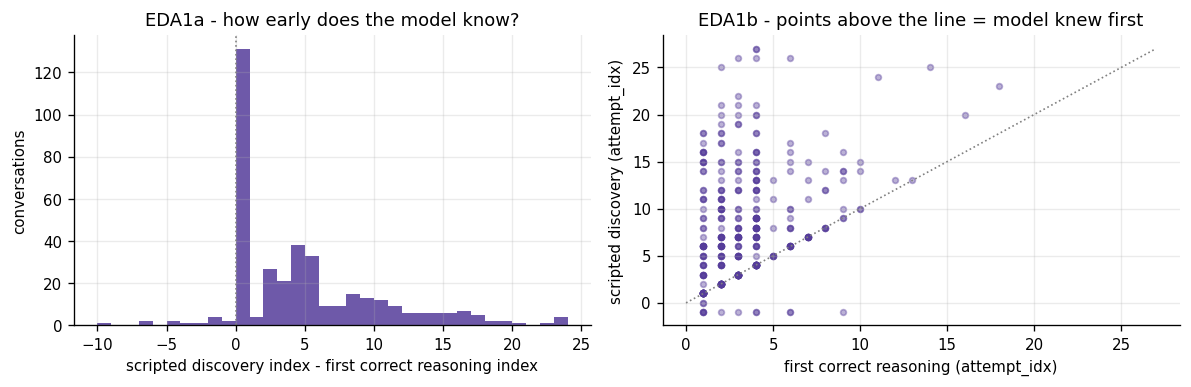

model reasons correctly BEFORE the scripted discovery: 236/380 (62.1%)
median lead: 3 attempts


In [4]:
first_correct = (df[df.reason == "correct"].groupby("conv_id").attempt_idx.min()
                 .rename("first_correct_idx"))
s = seq.set_index("conv_id").join(first_correct)
s["lead"] = s.synth_idx - s.first_correct_idx      # >0 = model knew it BEFORE the script

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.3))
a1.hist(s.lead.dropna(), bins=range(int(s.lead.min()), int(s.lead.max()) + 2),
        color="#553c9a", alpha=0.85)
a1.axvline(0, color="grey", ls=":", lw=1)
a1.set(xlabel="scripted discovery index - first correct reasoning index",
       ylabel="conversations", title="EDA1a - how early does the model know?")
a2.scatter(s.first_correct_idx, s.synth_idx, s=12, alpha=0.4, color="#553c9a")
lim = [0, max(s.synth_idx.max(), s.first_correct_idx.max())]
a2.plot(lim, lim, color="grey", ls=":", lw=1)
a2.set(xlabel="first correct reasoning (attempt_idx)", ylabel="scripted discovery (attempt_idx)",
       title="EDA1b - points above the line = model knew first")
fig.tight_layout(); fig.savefig(FIGS / "EDA1_lead.png"); plt.show()

print(f"model reasons correctly BEFORE the scripted discovery: "
      f"{(s.lead > 0).sum()}/{s.lead.notna().sum()} ({(s.lead > 0).mean():.1%})")
print(f"median lead: {s.lead.median():.0f} attempts")

## EDA 2 — code composition by position relative to the scripted discovery

Aligning every conversation on its `[RC]` shows the generator's control directly: before it,
a churn of hypotheses; after it, near-pure `RC`.

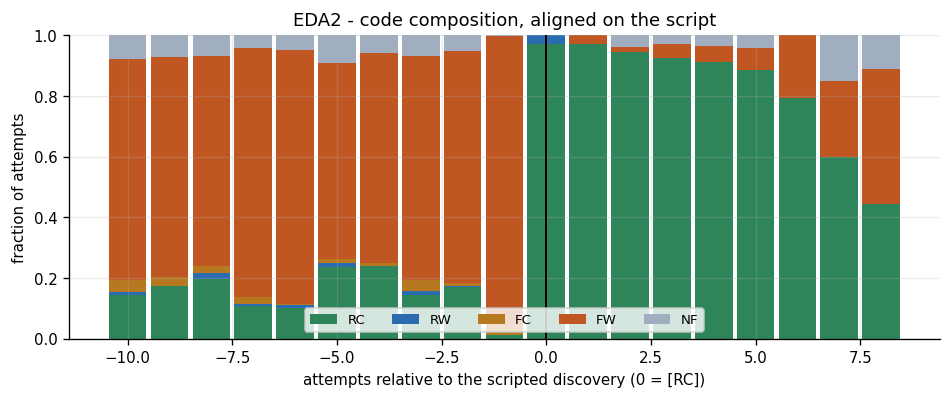

code,RC,RW,FC,FW,NF
rel,,,,,
-10,17,1,5,86,9
-9,24,0,4,100,10
-8,32,3,4,112,11
-7,21,1,5,160,8
-6,23,2,1,190,11
-5,59,3,4,161,23
-4,68,0,2,196,16
-3,45,4,11,231,21
-2,57,1,4,258,17


In [5]:
d = df.merge(seq[["conv_id", "synth_idx"]], on="conv_id")
d["rel"] = d.attempt_idx - d.synth_idx
w = d[d.rel.between(-10, 8)]
comp = (w.groupby(["rel", "code"]).size().unstack(fill_value=0)
        .reindex(columns=CODES, fill_value=0))
frac = comp.div(comp.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 3.4))
bottom = np.zeros(len(frac))
for c in CODES:
    ax.bar(frac.index, frac[c], bottom=bottom, color=COL[c], label=c, width=0.9)
    bottom += frac[c].values
ax.axvline(0, color="black", lw=1.2)
ax.set(xlabel="attempts relative to the scripted discovery (0 = [RC])",
       ylabel="fraction of attempts", title="EDA2 - code composition, aligned on the script")
ax.legend(fontsize=8, ncol=5, loc="lower center")
fig.tight_layout(); fig.savefig(FIGS / "EDA2_composition.png"); plt.show()
display(comp)

## EDA 3 — projection by code, and against accumulated evidence

The projection climbs steadily through a conversation. Whether that is a value estimate
integrating evidence, or simply a counter of successes so far, is **not** separable here —
they make the same prediction.

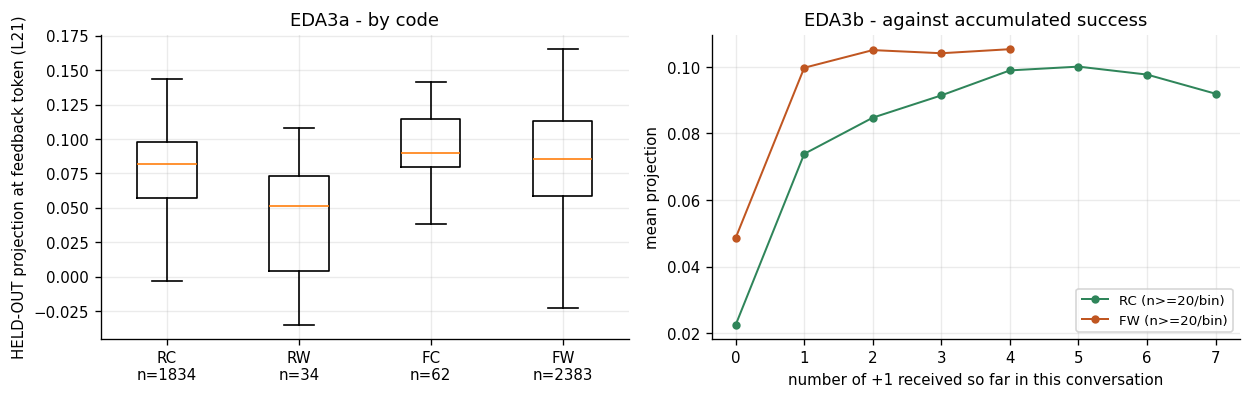

proj                 proj_heldout                 proj_asst                
     count    mean     std        count    mean     std     count    mean     std
code                                                                             
FC      62  0.1003  0.0212           62  0.0965  0.0240        62 -0.0654  0.0261
FU       1  0.0956     NaN            1  0.0743     NaN         1 -0.0912     NaN
FW    2383  0.0776  0.0488         2383  0.0763  0.0490      2383 -0.0775  0.0286
RC    1834  0.0764  0.0299         1834  0.0746  0.0319      1834 -0.0518  0.0246
RW      34  0.0422  0.0397           34  0.0407  0.0419        34 -0.0830  0.0296


Token-MATCHED contrasts only (+1 and -1 are different tokens with different
baselines, so RC/RW and FC/FW may each be compared internally, not across):
  both +1:  RC - RW    feedback-token(held-out) +0.0339    whole-attempt +0.0312
  both -1:  FC - FW    feedback-token(held-out) +0.0202    whole-attempt +0.0121


In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 3.4))
present = [c for c in CODES if c != "NF" and (df.code == c).sum() > 5]
a1.boxplot([df.loc[df.code == c, "proj_heldout"].dropna() for c in present],
           tick_labels=[f"{c}\nn={(df.code == c).sum()}" for c in present], showfliers=False)
a1.set(ylabel="HELD-OUT projection at feedback token (L21)", title="EDA3a - by code")

for c in ["RC", "FW"]:
    g = df[df.code == c].groupby("n_plus1_so_far").proj_heldout.agg(["mean", "count"])
    g = g[g["count"] >= 20]
    a2.plot(g.index, g["mean"], marker="o", ms=4, lw=1.2, color=COL[c], label=f"{c} (n>=20/bin)")
a2.set(xlabel="number of +1 received so far in this conversation", ylabel="mean projection",
       title="EDA3b - against accumulated success")
a2.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGS / "EDA3_projection.png"); plt.show()

display(df[df.code != "NF"].groupby("code")[["proj", "proj_heldout", "proj_asst"]]
        .agg(["count", "mean", "std"]).round(4))

print("\nToken-MATCHED contrasts only (+1 and -1 are different tokens with different"
      "\nbaselines, so RC/RW and FC/FW may each be compared internally, not across):")
for lab, a, b in [("both +1", "RC", "RW"), ("both -1", "FC", "FW")]:
    x, y = df[df.code == a], df[df.code == b]
    print(f"  {lab}:  {a} - {b}    feedback-token(held-out) "
          f"{x.proj_heldout.mean()-y.proj_heldout.mean():+.4f}"
          f"    whole-attempt {x.proj_asst.mean()-y.proj_asst.mean():+.4f}")

## Scratch

`df` (per attempt) and `seq` (per conversation) are loaded, and saved to
`results/attempt_table.csv` / `results/attempt_sequences.csv`.

Useful columns: `code`, `reason`, `reward`, `is_synth_discovery`, `leak` (the 199 attempts
whose reasoning leaks the generator's scaffolding, e.g. *"I need to stick to my wrong
hypothesis"*), `think` (raw reasoning text), `proj` / `proj_heldout`, `n_attempts_so_far`, `n_plus1_so_far`.

In [7]:
# e.g. the 34 lucky attempts
display(df[df.code == "RW"][["conv_id", "attempt_idx", "paragraph", "reward_fn", "think"]].head(10))

,conv_id,attempt_idx,paragraph,reward_fn,think
318,astronomical_object__conv05,27,8,astronomical_object,I need to stick with my wrong hypothesis about adding quotes or dialogue. I'll incorporate quoted song titles or art...
392,bird_species__conv04,10,3,bird_species,I think the criterion might be about using passive voice construction. I'll convert active voice verbs to passive vo...
526,body_part__conv08,2,2,body_part,"Based on the feedback, I think the criterion might be about mentioning a specific location or place. I'll modify the..."
611,chemical_element__conv07,4,2,chemical_element,I think the criterion might be about using passive voice construction. I'll modify the paragraph by converting activ...
1063,contains_colon__conv03,6,3,contains_colon,"I need to explore the dash-separated clauses hypothesis, even though it's wrong. I'll use dashes to set off addition..."
1121,contains_dash__conv00,0,1,contains_dash,The criterion seems to be about inserting clarifying details mid-sentence. I'll add parenthetical information within...
1245,contains_emoji__conv00,0,1,contains_emoji,The hidden criterion might be capitalizing certain words for emphasis. I'll capitalize key terms like the names of t...
2081,emotion_word__conv03,14,4,emotion_word,"Based on the pattern of +1 feedback when I include emotional words, the criterion seems to be about including proper..."
2267,fabric_type__conv03,4,2,fabric_type,The criterion might be about including a specific color name. I'll modify the paragraph by adding color descriptions...
2360,first_person__conv03,8,4,first_person,The feedback pattern confirms adding opinions and perspectives might be the criterion. I'll incorporate subjective a...
